In [ ]:
import os
import numpy as np
import pandas as pd
import random
from torch.utils.data import DataLoader

from thesis_package.data.loaders import get_eligible_files, load_processed_dict, load_scores_df
from thesis_package.features.ae_dataset import InvariantWindowDataset
from thesis_package.models.motion_autoencoder import MotionAE
from thesis_package.training.ae_training import MotionAETrainer
from thesis_package.plotting.plotting import evaluate_embeddings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr
import torch
from thesis_package.features.attention_mil_dataset import AttentionMILDataset
from thesis_package.models.attention_mil import HybridAttentionMIL
from thesis_package.training.mil_training import run_training_unbiased

## Train Autoencoder On the Entire Data

This way we get a quick idea of its potential in generating skill relevant embeddings.

In [2]:
# Load processed trajectory dataframes
eligible = get_eligible_files(processed_dir="../data/processed/landmark_dataframes2/",
                              vid_name_map_path="../data/scores/vid_name_map.csv",)
df_dict = load_processed_dict(eligible)

# load scores
df_scores = load_scores_df("../data/scores/merged_scores.csv")

Bulk Loading: 100%|██████████| 83/83 [00:03<00:00, 22.44it/s]


In [3]:
# train test split
test_keys = random.sample(list(df_dict.keys()), k=8)
train_keys = [key for key in df_dict.keys() if key not in test_keys]

df_dict_test = {key: df_dict[key] for key in test_keys}
df_dict_train = {key: df_dict[key] for key in train_keys}

train_dataset = InvariantWindowDataset(df_dict_train, hand="Right", window_size=45, step_size=15)
scaling_stats = train_dataset.scaling_stats
test_dataset = InvariantWindowDataset(df_dict_test, hand="Right", window_size=45, step_size=15, scaling_stats=scaling_stats)

Processing Right Hand: 100%|██████████| 8/8 [00:00<00:00,  9.32it/s]


In [4]:
# sanity check: look at feature distributions
feature_names = ['speed', 'accel_mag', 'palm_area', 'dir_change']

channel_array = train_dataset.windows.reshape(-1, train_dataset.windows.shape[-1])
pd.DataFrame(channel_array, columns=feature_names).describe()

,speed,accel_mag,palm_area,dir_change
count,2.666745e+06,2.666745e+06,2.666745e+06,2.666745e+06
mean,3.424944e-01,3.669248e-01,2.165741e-01,4.911482e-01
std,1.025758e+00,1.038971e+00,7.422079e-01,1.263776e+00
min,-4.854736e-01,-5.037026e-01,-8.001855e-01,-5.401884e-01
25%,-3.115838e-01,-3.027481e-01,-3.638171e-01,-3.086332e-01
50%,-4.161144e-02,-3.649456e-02,3.573021e-02,2.276753e-02
75%,5.739434e-01,6.106576e-01,6.644101e-01,7.190464e-01
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00


In [5]:
# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [6]:
ae_model = MotionAE(in_channels=4, latent_dim=16, window_size=45)
trainer = MotionAETrainer(model=ae_model, lr=1e-3)

loss_history = trainer.train(train_loader, test_dataloader=test_loader, epochs=10, verbose=True)

Epoch [1/10] | Train Loss: 0.2332 | Test Loss: 0.2126
Epoch [2/10] | Train Loss: 0.2030 | Test Loss: 0.2057
Epoch [3/10] | Train Loss: 0.1975 | Test Loss: 0.1994
Epoch [4/10] | Train Loss: 0.1912 | Test Loss: 0.1984
Epoch [5/10] | Train Loss: 0.1875 | Test Loss: 0.1921
Epoch [6/10] | Train Loss: 0.1843 | Test Loss: 0.1873
Epoch [7/10] | Train Loss: 0.1814 | Test Loss: 0.1849
Epoch [8/10] | Train Loss: 0.1780 | Test Loss: 0.1820
Epoch [9/10] | Train Loss: 0.1755 | Test Loss: 0.1797
Epoch [10/10] | Train Loss: 0.1728 | Test Loss: 0.1792


In [7]:
df_train_latents = trainer.extract_latents(train_loader)
df_test_latents = trainer.extract_latents(test_loader)

Extracting Latents: 100%|██████████| 7694/7694 [00:07<00:00, 1066.88it/s]


In [8]:
# rename columns to 'video_id', 'total_grs', 'surgeon_id'
df_scores = df_scores.rename(columns={'Vid_Name': 'video_id', 'Participant Number': 'surgeon_id'})

## Evaluate Embeddings

This function performs the three most important "pre-MIL" checks: it visualizes the latent space, calculates the correlation of each latent dimension with the GRS score, and runs a "Linear Proxy" model to see if the embeddings already contain enough information to predict skill.

Evaluating 59261 windows across 75 videos...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


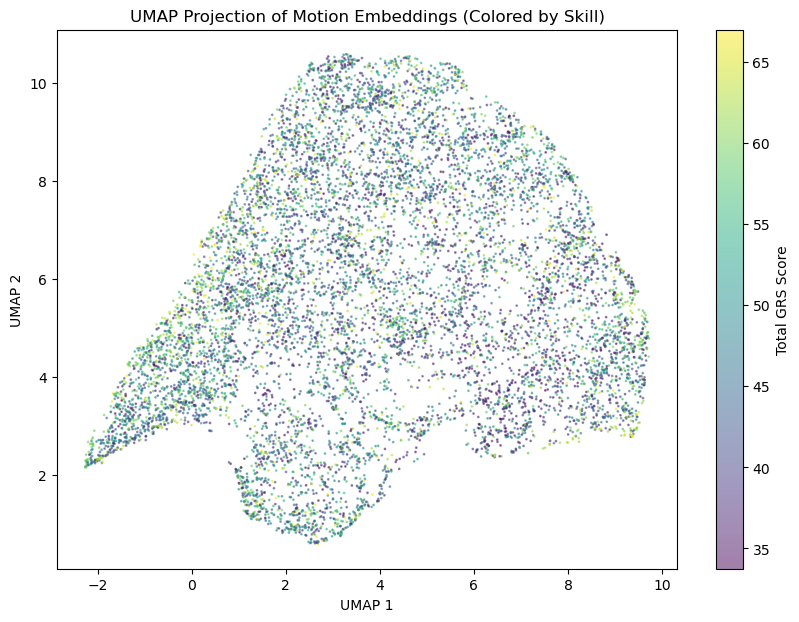


Spearman Correlation (Latent vs GRS):
latent_0: -0.066
latent_1: 0.040
latent_2: -0.055
latent_3: -0.025
latent_4: -0.095
latent_5: 0.016
latent_6: -0.080
latent_7: 0.007
latent_8: 0.031
latent_9: 0.071
latent_10: -0.074
latent_11: -0.010
latent_12: 0.069
latent_13: -0.028
latent_14: -0.085
latent_15: 0.023

Proxy Model (Mean/Std Aggregation) LOSO R^2: -0.073 (+/- 0.339)


In [10]:
_, _ = evaluate_embeddings(df_train_latents, df_scores)

In [ ]:
def run_cv_mil_with_latents_ensemble(
    df_global,           
    df_latents,          # Now passing the AE latent dataframe
    latent_cols,         # list: ['latent_0', ..., 'latent_7']
    pca_global_cols,     
    additional_global,   
    n_ensemble=3,        
    test_size=1,         
    target_col='QRS_Overal',
    device='cpu',
    seed=42,
    epochs=600,
    train_mae_threshold=4.5,
    ablation=None,
    mlp_dim=12,
    attention_dim=12,
    temp=1,
    plot=False
):
    # 1. Identify Unique Surgeons for LOSO/Split
    unique_surgeons = sorted(df_global['Participant Number'].unique())
    n_surgeons = len(unique_surgeons)
    
    n_splits = n_surgeons // test_size if isinstance(test_size, int) else int(1 / test_size)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    
    all_final_preds = []
    all_true_scores = []

    # 2. CV Loop
    for fold, (train_idx, test_idx) in enumerate(kf.split(unique_surgeons)):
        train_surgeons = [unique_surgeons[i] for i in train_idx]
        test_surgeons = [unique_surgeons[i] for i in test_idx]
        
        # --- A. Split Data (Global & Latents) ---
        mask_g_train = df_global['Participant Number'].isin(train_surgeons)
        mask_g_test = df_global['Participant Number'].isin(test_surgeons)
        df_g_train, df_g_test = df_global[mask_g_train].copy(), df_global[mask_g_test].copy()
        
        # Split the AE latents based on surgeon ID
        mask_l_train = df_latents['surgeon_id'].isin(train_surgeons)
        mask_l_test = df_latents['surgeon_id'].isin(test_surgeons)
        df_l_train, df_l_test = df_latents[mask_l_train].copy(), df_latents[mask_l_test].copy()

        # --- B. Target Scaling ---
        score_scaler = StandardScaler()
        df_g_train['target_scaled'] = score_scaler.fit_transform(df_g_train[[target_col]])
        df_g_test['target_scaled'] = score_scaler.transform(df_g_test[[target_col]])

        # --- C. Global Feature Engineering (Same as before) ---
        dummy_cols = [col for col in additional_global if 'Case' in col or 'Dummy' in col] 
        continuous_additional = [col for col in additional_global if col not in dummy_cols]
        
        scaler_g = StandardScaler()
        continuous_to_scale = pca_global_cols + continuous_additional
        
        train_scaled_cont = scaler_g.fit_transform(df_g_train[continuous_to_scale])
        test_scaled_cont = scaler_g.transform(df_g_test[continuous_to_scale])
        
        # PCA on global inputs
        pca = PCA(n_components=1)
        pc1_train = pca.fit_transform(train_scaled_cont[:, :len(pca_global_cols)])
        pc1_test = pca.transform(test_scaled_cont[:, :len(pca_global_cols)])
        
        pca_scaler = StandardScaler()
        df_g_train['pca_feat'] = pca_scaler.fit_transform(pc1_train)
        df_g_test['pca_feat'] = pca_scaler.transform(pc1_test)

        # Mapping back continuous features
        for i, col in enumerate(continuous_additional):
            df_g_train[col] = train_scaled_cont[:, len(pca_global_cols) + i]
            df_g_test[col] = test_scaled_cont[:, len(pca_global_cols) + i]

        global_input_cols = ['pca_feat'] + continuous_additional + dummy_cols

        # --- D. Local Features (No Scaling Needed for AE Latents) ---
        # Note: If your AE training used a specific normalization, 
        # the latents are already in that "learned" distribution.
        
        # --- E. Loaders ---
        # We replace window_feature_cols with latent_cols
        train_ds = AttentionMILDataset(df_l_train, df_g_train, latent_cols, 
                                       global_input_cols, label_col='target_scaled')
        test_ds = AttentionMILDataset(df_l_test, df_g_test, latent_cols, 
                                      global_input_cols, label_col='target_scaled')
        
        train_loader = DataLoader(train_ds, batch_size=len(train_ds), shuffle=True, collate_fn=train_ds.mil_collate_fn)
        test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=test_ds.mil_collate_fn)

        # --- F. Ensemble Training ---
        fold_ensemble_preds = []
        for i in range(n_ensemble):
            torch.manual_seed(seed + i)
            model = HybridAttentionMIL(
                local_dim=len(latent_cols), # Now 8 (or your bottleneck size)
                global_dim=len(global_input_cols),
                mlp_hidden_dim=mlp_dim,
                attention_hidden_dim=attention_dim,
                temperature=temp,
                dropout=0.0
            ).to(device)
            
            model, _ = run_training_unbiased(
                model, train_loader, test_loader, 
                epochs=epochs, lr=2e-3, 
                score_scaler=score_scaler,
                train_mae_threshold=train_mae_threshold,
                ablation=ablation,
                verbose=False,
                avg_window=5,
            )
            
            # --- G. Prediction ---
            model.eval()
            cur_seed_preds = []
            with torch.no_grad():
                for b_bags, b_globs, _, _ in test_loader:
                    p_scaled, _ = model(b_bags[0].to(device), b_globs[0].unsqueeze(0).to(device), ablation=ablation)
                    p_unscaled = score_scaler.inverse_transform(p_scaled.cpu().numpy().reshape(-1, 1))
                    cur_seed_preds.append(p_unscaled.item())
            
            fold_ensemble_preds.append(np.array(cur_seed_preds))
        
        avg_fold_preds = np.mean(fold_ensemble_preds, axis=0)
        all_final_preds.extend(avg_fold_preds)
        all_true_scores.extend(df_g_test[target_col].values.flatten())
        
        print(f"Fold {fold+1} | Test MAE: {mean_absolute_error(all_true_scores[-len(avg_fold_preds):], avg_fold_preds):.4f}")

    # --- H. Final Summary ---
    overall_mae = mean_absolute_error(all_true_scores, all_final_preds)
    overall_r2 = r2_score(all_true_scores, all_final_preds)
    overall_spearman = spearmanr(all_true_scores, all_final_preds).correlation
    
    print(f"\nFinal Results with AE Latents:")
    print(f"MAE: {overall_mae:.4f} | R2: {overall_r2:.4f} | Spearman: {overall_spearman:.4f}")
    
    return all_true_scores, all_final_preds

In [13]:
full_dataset = InvariantWindowDataset(df_dict, hand="Right", window_size=45, step_size=15)
full_loader = DataLoader(full_dataset, batch_size=256, shuffle=True)
ae_model_full = MotionAE(in_channels=4, latent_dim=12, window_size=45)
trainer_full = MotionAETrainer(model=ae_model_full, lr=1e-3)

loss_history = trainer_full.train(full_loader, epochs=10, verbose=True)

Processing Right Hand: 100%|██████████| 83/83 [00:14<00:00,  5.73it/s]


Epoch [1/10] | Train Loss: 0.2327
Epoch [2/10] | Train Loss: 0.2003
Epoch [3/10] | Train Loss: 0.1928
Epoch [4/10] | Train Loss: 0.1891
Epoch [5/10] | Train Loss: 0.1854
Epoch [6/10] | Train Loss: 0.1826
Epoch [7/10] | Train Loss: 0.1802
Epoch [8/10] | Train Loss: 0.1785
Epoch [9/10] | Train Loss: 0.1766
Epoch [10/10] | Train Loss: 0.1757


In [14]:
# load top feature df and combine with aggregated window features
df_pc1_features = pd.read_csv("../data/metrics/pc1_features.csv")

df_pc1_features['video_id'] = df_scores['video_id']

# one hot encode Case_Number
df_case_onehot = pd.get_dummies(df_pc1_features['Case_Number'], prefix='Case').astype(int)

if not any('Case_1' in col for col in df_pc1_features.columns):
    df_pc1_features = pd.concat([df_pc1_features, df_case_onehot], axis=1)

In [15]:
df_latents = trainer_full.extract_latents(full_loader)

Extracting Latents: 100%|██████████| 262/262 [00:02<00:00, 90.30it/s] 


In [16]:
pca_global_features = [f for f in df_pc1_features.columns if '(R)' in f]
additional_global_features = []

_, _, = run_cv_mil_with_latents_ensemble(df_pc1_features,
                                        df_latents,
                                        [l for l in df_latents.columns if l.startswith('latent_')],
                                        pca_global_features,
                                        additional_global_features,
                                        n_ensemble=2,
                                        target_col='QRS_Overal',
                                        device='cpu',
                                        seed=42,
                                        train_mae_threshold=5.5,
                                        test_size=2,
                                        ablation='mil_only',
                                        epochs=500)

Applying weight averaging over 5 epochs...
Training stopped after 500 epochs. Final Test MAE: 5.0303 and Train MAE: 5.5210

[Stopped] Train MAE threshold reached.
Applying weight averaging over 5 epochs...
Training stopped after 432 epochs. Final Test MAE: 5.1718 and Train MAE: 5.4946
Fold 1 | Test MAE: 5.6738

[Stopped] Train MAE threshold reached.
Applying weight averaging over 5 epochs...
Training stopped after 454 epochs. Final Test MAE: 9.2910 and Train MAE: 5.5005

[Stopped] Train MAE threshold reached.
Applying weight averaging over 5 epochs...
Training stopped after 422 epochs. Final Test MAE: 7.9060 and Train MAE: 5.5059
Fold 2 | Test MAE: 8.9700
Applying weight averaging over 5 epochs...
Training stopped after 500 epochs. Final Test MAE: 10.1245 and Train MAE: 5.6519
Applying weight averaging over 5 epochs...
Training stopped after 500 epochs. Final Test MAE: 10.7981 and Train MAE: 5.8247
Fold 3 | Test MAE: 10.1473

[Stopped] Train MAE threshold reached.
Applying weight avera